# 05 — Anomaly Detection Development

LSTM-Autoencoder pretraining on LogHub HDFS and evaluation.

**Runtime:** Google Colab Pro (T4/L4/A100 GPU recommended)

## Workflow
1. Setup environment and load HDFS data
2. Create model with dynamic `input_dim` from Drain3 templates
3. Pretrain on normal HDFS sequences
4. Plot training curves
5. Calculate threshold on holdout normal data
6. Evaluate on HDFS benchmark (precision/recall/F1)
7. Fine-tune on OTel Demo (placeholder — requires log collection)

In [1]:
%pip install drain3 scikit-learn

  Preparing metadata (setup.py) ... done
  Created wheel for drain3: filename=drain3-0.9.11-py3-none-any.whl size=23998 sha256=7a1e25aac34ce188785c9d1e279a219de43629de475b198b32506f6bd18fe21a
  Stored in directory: /root/.cache/pip/wheels/3f/d1/46/58e1747b3d77c4990f838e1c1f610f5aab1a21889cc9bff5c2
Successfully built drain3
  Attempting uninstall: jsonpickle
    Found existing installation: jsonpickle 4.1.1
    Uninstalling jsonpickle-4.1.1:
      Successfully uninstalled jsonpickle-4.1.1
  Attempting uninstall: cachetools
    Found existing installation: cachetools 6.2.6
    Uninstalling cachetools-6.2.6:
      Successfully uninstalled cachetools-6.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyiceberg 0.11.1 requires cachetools<7.0,>=5.5, but you have cachetools 4.2.1 which is incompatible.


In [2]:
# Cell 1: Setup
# If running on Google Colab, uncomment the following lines:

from google.colab import drive
drive.mount('/content/drive')
# !pip install drain3 scikit-learn

import sys
import os

# Add project root to path (adjust if repo is in a different location)
# For Colab: sys.path.insert(0, '/content/drive/MyDrive/Colab Notebooks/opsagent')
# For local: sys.path.insert(0, '..')
sys.path.insert(0, '/content/drive/MyDrive/Colab Notebooks/opsagent')

import numpy as np
import torch
import matplotlib.pyplot as plt

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4


In [3]:
# Cell 2: Load HDFS data
from src.preprocessing.log_parser import LogParser
from src.preprocessing.loghub_preprocessor import LogHubHDFSPreprocessor

HDFS_DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/opsagent/data/LogHub/HDFS/'  # Adjust for Colab

# Create shared parser (will be reused for OTel fine-tuning later)
parser = LogParser(persistence_path='/content/drive/MyDrive/Colab Notebooks/opsagent/models/drain3/')

preprocessor = LogHubHDFSPreprocessor(
    data_dir=HDFS_DATA_PATH,
    seq_length=10,
    parser=parser,
)
preprocessor.parse()

n_templates = preprocessor.num_templates
print(f'Templates discovered: {n_templates}')
print(f'Blocks parsed: {len(preprocessor._block_sequences)}')

# Get sequences
normal_seqs = preprocessor.get_normal_sequences()
anomalous_seqs = preprocessor.get_anomalous_sequences()
print(f'Normal sequences: {normal_seqs.shape}')
print(f'Anomalous sequences: {anomalous_seqs.shape}')
print(f'Anomaly rate: {len(anomalous_seqs) / (len(normal_seqs) + len(anomalous_seqs)):.4f}')

Templates discovered: 115
Blocks parsed: 575061
Normal sequences: (1608443, 10)
Anomalous sequences: (42785, 10)
Anomaly rate: 0.0259


In [4]:
# Cell 3: Create model and pretrain
from src.anomaly_detection.pretrain_on_loghub import pretrain_on_hdfs

CHECKPOINT_PATH = '/content/drive/MyDrive/Colab Notebooks/opsagent/models/lstm_autoencoder/pretrained_hdfs.pt'

# Pretrain — epochs=50, batch_size=64, lr=0.001, patience=5
model, parser = pretrain_on_hdfs(
    hdfs_data_path=HDFS_DATA_PATH,
    model_save_path=CHECKPOINT_PATH,
    parser=parser,
)

print(f'\nModel parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Checkpoint saved to: {CHECKPOINT_PATH}')

Parsing HDFS.log (this may take several minutes)...
  Templates discovered: 115
  Normal sequences: 1608443
  Train: (1286754, 10, 115), Val: (321689, 10, 115)
Epoch 1/50  train_loss=0.000444  val_loss=0.000078
Epoch 2/50  train_loss=0.000072  val_loss=0.000032
Epoch 3/50  train_loss=0.000043  val_loss=0.000024
Epoch 4/50  train_loss=0.000035  val_loss=0.000061
Epoch 5/50  train_loss=0.000032  val_loss=0.000021
Epoch 6/50  train_loss=0.000028  val_loss=0.000028
Epoch 7/50  train_loss=0.000028  val_loss=0.000022
Epoch 8/50  train_loss=0.000025  val_loss=0.000017
Epoch 9/50  train_loss=0.000025  val_loss=0.000018
Epoch 10/50  train_loss=0.000023  val_loss=0.000027
Epoch 11/50  train_loss=0.000022  val_loss=0.000015
Epoch 12/50  train_loss=0.000020  val_loss=0.000016
Epoch 13/50  train_loss=0.000020  val_loss=0.000014
Epoch 14/50  train_loss=0.000020  val_loss=0.000015
Epoch 15/50  train_loss=0.000019  val_loss=0.000032
Epoch 16/50  train_loss=0.000019  val_loss=0.000014
Epoch 17/50  trai

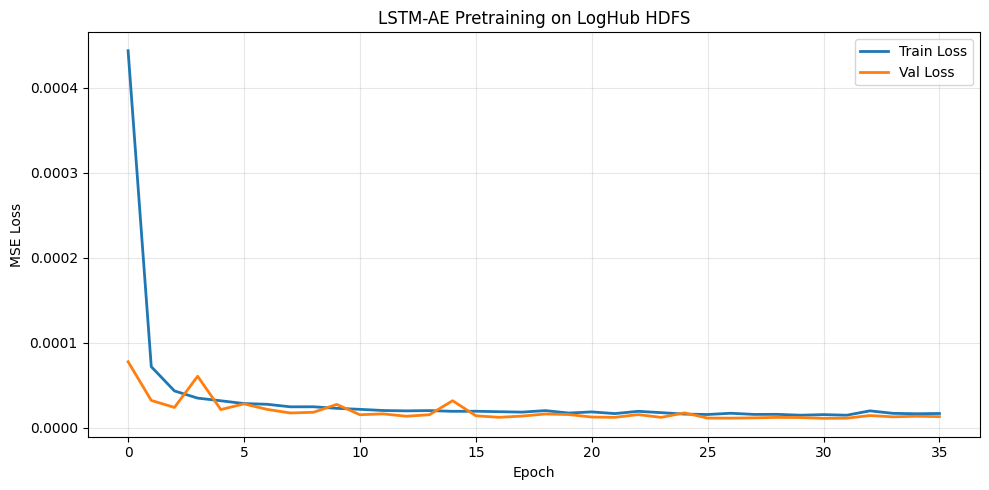

Final train loss: 0.000017
Final val loss:   0.000013
Total epochs:     36


In [5]:
# Cell 4: Plot training curves
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
history = checkpoint['history']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM-AE Pretraining on LogHub HDFS')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/opsagent/docs/images/hdfs_pretraining_curves.png', dpi=150)
plt.show()

print(f'Final train loss: {history["train_loss"][-1]:.6f}')
print(f'Final val loss:   {history["val_loss"][-1]:.6f}')
print(f'Total epochs:     {len(history["train_loss"])}')

In [6]:
# Cell 5: Calculate threshold on holdout normal data
from src.anomaly_detection.pretrain_on_loghub import _one_hot_encode
from src.anomaly_detection.threshold import calculate_threshold
from sklearn.model_selection import train_test_split

# Split normal sequences — use the validation portion for threshold
_, holdout_seqs = train_test_split(normal_seqs, test_size=0.2, random_state=42)

# One-hot encode for model input
holdout_data = _one_hot_encode(holdout_seqs, n_templates)
print(f'Holdout sequences for threshold: {holdout_data.shape}')

# Calculate 95th percentile threshold
device = 'cuda' if torch.cuda.is_available() else 'cpu'
threshold = calculate_threshold(
    model, holdout_data, percentile=95, batch_size=256, device=device
)
print(f'\n95th percentile threshold: {threshold:.6f}')

Holdout sequences for threshold: (321689, 10, 115)
Threshold calculation (p95):
  Samples:   321689
  Mean error: 0.000046
  Std error:  0.000428
  Threshold:  0.000003

95th percentile threshold: 0.000003


In [7]:
# Cell 6: HDFS Benchmark — evaluate on labeled data
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# One-hot encode anomalous sequences
anomalous_data = _one_hot_encode(anomalous_seqs, n_templates)

# Score all sequences
model.eval()
model.to(device)

def get_errors(data, batch_size=256):
    errors = []
    for i in range(0, len(data), batch_size):
        batch = torch.FloatTensor(data[i:i+batch_size]).to(device)
        with torch.no_grad():
            err = model.get_reconstruction_error(batch)
            errors.extend(err.cpu().tolist())
    return np.array(errors)

normal_errors = get_errors(holdout_data)
anomalous_errors = get_errors(anomalous_data)

# Classify using threshold
all_errors = np.concatenate([normal_errors, anomalous_errors])
all_labels = np.concatenate([
    np.zeros(len(normal_errors), dtype=int),
    np.ones(len(anomalous_errors), dtype=int),
])
predictions = (all_errors > threshold).astype(int)

print('HDFS Benchmark Results:')
print(f'  Threshold: {threshold:.6f}')
print(f'  Normal samples:    {len(normal_errors)}')
print(f'  Anomalous samples: {len(anomalous_errors)}')
print()
print(classification_report(all_labels, predictions, target_names=['Normal', 'Anomaly']))

f1 = f1_score(all_labels, predictions)
precision = precision_score(all_labels, predictions)
recall = recall_score(all_labels, predictions)
print(f'F1: {f1:.4f}  Precision: {precision:.4f}  Recall: {recall:.4f}')

HDFS Benchmark Results:
  Threshold: 0.000003
  Normal samples:    321689
  Anomalous samples: 42785

              precision    recall  f1-score   support

      Normal       0.94      0.95      0.95    321689
     Anomaly       0.60      0.56      0.58     42785

    accuracy                           0.90    364474
   macro avg       0.77      0.75      0.76    364474
weighted avg       0.90      0.90      0.90    364474

F1: 0.5771  Precision: 0.5978  Recall: 0.5578


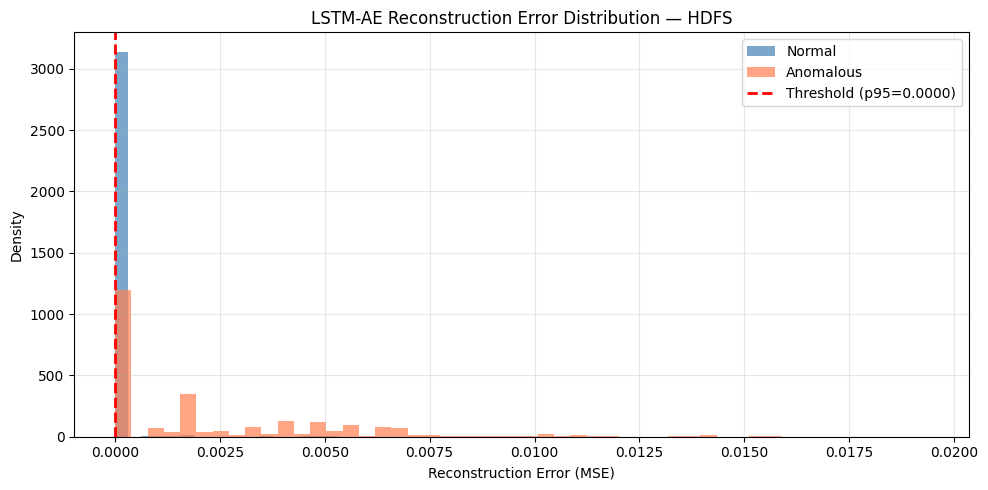

In [8]:
# Cell 7: Error distribution visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(normal_errors, bins=50, alpha=0.7, label='Normal', color='steelblue', density=True)
ax.hist(anomalous_errors, bins=50, alpha=0.7, label='Anomalous', color='coral', density=True)
ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold (p95={threshold:.4f})')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('LSTM-AE Reconstruction Error Distribution — HDFS')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/opsagent/docs/images/hdfs_error_distribution.png', dpi=150)
plt.show()

In [ ]:
# Cell 8: Fine-tune on OTel Demo (placeholder)
# This cell will be runnable after Week 6.5 when Promtail is configured
# and a log-enriched baseline has been collected.
#
# from src.anomaly_detection.pretrain_on_loghub import finetune_on_otel_demo
#
# otel_data = {
#     'train': train_features,    # np.ndarray (N, seq_len, feature_dim)
#     'val': val_features,        # np.ndarray (M, seq_len, feature_dim)
#     'input_dim': feature_dim,   # int from FeatureEngineer.feature_dim
# }
#
# finetuned_model = finetune_on_otel_demo(
#     pretrained_model_path='../models/lstm_autoencoder/pretrained_hdfs.pt',
#     otel_data=otel_data,
#     model_save_path='../models/lstm_autoencoder/finetuned_otel.pt',
# )

print('OTel Demo fine-tuning: DEFERRED')
print('Requires: Promtail log collection + 4-8h baseline with logs+metrics')
print('See PROGRESS.md Week 6.5 tasks')